In [1]:
# =========================================================
# CELL 1
# IMPORTS + DEVICE
# =========================================================

import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

from PIL import Image

import torchvision.transforms as T
import torchvision.models as models

import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)

DEVICE: cpu


In [2]:
# =========================================================
# CELL 2
# WHAT STREAM MODEL
# =========================================================

class WhatStreamCNN(nn.Module):

    def __init__(self, num_classes=3):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 8 * 8, 256),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        return self.classifier(self.features(x))

In [3]:
# =========================================================
# CELL 3
# WHERE STREAM MODEL
# =========================================================

class ConvBNReLU(nn.Module):

    def __init__(self, in_ch, out_ch):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),

            nn.BatchNorm2d(out_ch),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.block(x)

class ResidualDoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):

        super().__init__()

        self.conv1 = ConvBNReLU(in_ch, out_ch)

        self.conv2 = nn.Sequential(

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),

            nn.BatchNorm2d(out_ch)
        )

        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential(

            nn.Conv2d(in_ch, out_ch, 1, bias=False),

            nn.BatchNorm2d(out_ch)

        ) if in_ch != out_ch else nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)

        out = self.conv2(out)

        return self.relu(out + identity)

class SqueezeExcitation(nn.Module):

    def __init__(self, channels, reduction=8):

        super().__init__()

        self.se = nn.Sequential(

            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),

            nn.Linear(channels, channels // reduction),

            nn.ReLU(),

            nn.Linear(channels // reduction, channels),

            nn.Sigmoid()
        )

    def forward(self, x):

        w = self.se(x).view(x.shape[0], x.shape[1], 1, 1)

        return x * w

class DecoderBlock(nn.Module):

    def __init__(self, in_ch, skip_ch, out_ch):

        super().__init__()

        self.upsample = nn.ConvTranspose2d(
            in_ch,
            in_ch // 2,
            2,
            stride=2
        )

        self.conv = ResidualDoubleConv(
            in_ch // 2 + skip_ch,
            out_ch
        )

        self.se = SqueezeExcitation(out_ch)

    def forward(self, x, skip):

        x = self.upsample(x)

        if x.shape[2:] != skip.shape[2:]:

            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode='bilinear',
                align_corners=False
            )

        x = torch.cat([x, skip], dim=1)

        x = self.conv(x)

        x = self.se(x)

        return x

class SEResUNet(nn.Module):

    def __init__(self, num_classes=5, image_size=224):

        super().__init__()

        self.image_size = image_size

        self.input_proj = nn.Sequential(

            nn.Conv2d(1, 3, 1, bias=False),

            nn.BatchNorm2d(3),

            nn.ReLU(inplace=True)
        )

        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        self.enc0 = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.pool = resnet.maxpool

        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4

        self.bottleneck = ResidualDoubleConv(2048, 1024)

        self.dec4 = DecoderBlock(1024, 1024, 512)
        self.dec3 = DecoderBlock(512, 512, 256)
        self.dec2 = DecoderBlock(256, 256, 128)

        self.aux_head = nn.Conv2d(128, num_classes, 1)

        self.dec1 = DecoderBlock(128, 64, 64)
        self.dec0 = DecoderBlock(64, 64, 32)

        self.final_head = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):

        x = self.input_proj(x)

        e0 = self.enc0(x)

        ep = self.pool(e0)

        e1 = self.enc1(ep)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        b = self.bottleneck(e4)

        d4 = self.dec4(b, e3)
        d3 = self.dec3(d4, e2)
        d2 = self.dec2(d3, e1)

        aux = self.aux_head(d2)

        aux = F.interpolate(
            aux,
            size=(self.image_size, self.image_size),
            mode='bilinear'
        )

        d1 = self.dec1(d2, ep)
        d0 = self.dec0(d1, e0)

        out = self.final_head(d0)

        if out.shape[2:] != (self.image_size, self.image_size):

            out = F.interpolate(
                out,
                size=(self.image_size, self.image_size),
                mode='bilinear'
            )

        return out, aux

In [4]:
# =========================================================
# CELL 4
# LOAD MODELS
# =========================================================

what_model = WhatStreamCNN().to(DEVICE)

what_model.load_state_dict(
    torch.load("best_model_as.pth", map_location=DEVICE)
)

what_model.eval()

print("What Stream Loaded")


where_model = SEResUNet().to(DEVICE)

state = torch.load(
    "se_resunet_results/SE_ResUNet_best.pth",
    map_location=DEVICE
)

state = {
    k.replace("module.",""):v
    for k,v in state.items()
}

where_model.load_state_dict(state)

where_model.eval()

print("Where Stream Loaded")

What Stream Loaded
Where Stream Loaded


In [5]:
# =========================================================
# CELL 5
# IMAGE PATH
# =========================================================

IMAGE_PATH = r"D:\whatstream dataset\wt imple new\dataset for evidence score\test\2\9062328R.png"

print(IMAGE_PATH)

D:\whatstream dataset\wt imple new\dataset for evidence score\test\2\9062328R.png


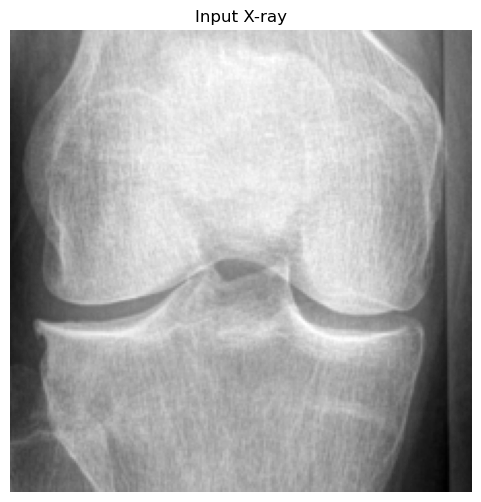

In [6]:
# =========================================================
# CELL 6
# SHOW INPUT IMAGE
# =========================================================

img = cv2.imread(IMAGE_PATH,0)

plt.figure(figsize=(6,6))

plt.imshow(img, cmap='gray')

plt.title("Input X-ray")

plt.axis('off')

plt.show()

In [7]:
# =========================================================
# CELL 7
# WHAT STREAM
# =========================================================

WINDOW = 32
STRIDE = 1
PAD = 15

img = Image.open(IMAGE_PATH).convert('L').resize((224,224))

img_tensor = T.Normalize([0.5],[0.5])(
    T.ToTensor()(img)
).unsqueeze(0)

padded = F.pad(
    img_tensor,
    (PAD,PAD+1,PAD,PAD+1),
    mode='reflect'
)

H, W = padded.shape[2], padded.shape[3]

out_h = (H-WINDOW)//STRIDE + 1
out_w = (W-WINDOW)//STRIDE + 1

prob_maps = np.zeros((3, out_h, out_w))

padded_np = padded.squeeze().numpy()

with torch.no_grad():

    for i in range(out_h):

        for j in range(out_w):

            patch = torch.tensor(
                padded_np[i:i+WINDOW, j:j+WINDOW]
            ).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

            probs = torch.softmax(
                what_model(patch),
                dim=1
            ).cpu().numpy()[0]

            prob_maps[:, i, j] = probs

print("What Stream Complete")

What Stream Complete


In [8]:
# =========================================================
# CELL 8
# SHOW + EXPORT PROBABILITY MAPS
# =========================================================

labels = [
    "JSN",
    "Background",
    "Osteophyte"
]

# =========================================================
# SAVE CSV FILES
# =========================================================

save_dir = r"D:\Probability evidence map"

os.makedirs(save_dir, exist_ok=True)

for i in range(3):

    df = pd.DataFrame(prob_maps[i])

    csv_path = os.path.join(
        save_dir,
        f"{labels[i]}_probability_map.csv"
    )

    df.to_csv(csv_path, index=False)

    print(f"Saved: {csv_path}")

# =========================================================
# SHOW SMALL MATRIX PREVIEW
# =========================================================

for i in range(3):

    print("\n===================================")
    print(labels[i], "Probability Map")
    print("Top-left 10x10 Region")
    print("===================================\n")

    small_region = prob_maps[i][:10, :10]

    preview_df = pd.DataFrame(
        np.round(small_region, 4)
    )

    print(preview_df)



Saved: D:\Probability evidence map\JSN_probability_map.csv
Saved: D:\Probability evidence map\Background_probability_map.csv
Saved: D:\Probability evidence map\Osteophyte_probability_map.csv

JSN Probability Map
Top-left 10x10 Region

        0       1       2       3       4       5       6       7       8  \
0  0.0072  0.0075  0.0083  0.0084  0.0095  0.0106  0.0122  0.0128  0.0141   
1  0.0071  0.0071  0.0081  0.0080  0.0094  0.0100  0.0117  0.0121  0.0136   
2  0.0071  0.0074  0.0084  0.0086  0.0101  0.0112  0.0130  0.0139  0.0158   
3  0.0077  0.0080  0.0092  0.0094  0.0110  0.0123  0.0145  0.0150  0.0171   
4  0.0079  0.0084  0.0096  0.0097  0.0114  0.0129  0.0151  0.0159  0.0183   
5  0.0088  0.0090  0.0102  0.0101  0.0117  0.0126  0.0148  0.0155  0.0174   
6  0.0090  0.0093  0.0106  0.0109  0.0126  0.0136  0.0158  0.0167  0.0187   
7  0.0100  0.0103  0.0117  0.0117  0.0135  0.0146  0.0172  0.0175  0.0192   
8  0.0108  0.0112  0.0126  0.0130  0.0152  0.0165  0.0191  0.0199  0.021

In [9]:
# =========================================================
# CELL 9
# WHERE STREAM SEGMENTATION
# =========================================================

img = cv2.imread(IMAGE_PATH,0)

original = img.copy()

img = cv2.resize(img,(224,224))/255.0

t = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

with torch.no_grad():

    out,_ = where_model(t)

    seg = torch.argmax(out,1).cpu().numpy()[0]

print("Segmentation Complete")

Segmentation Complete


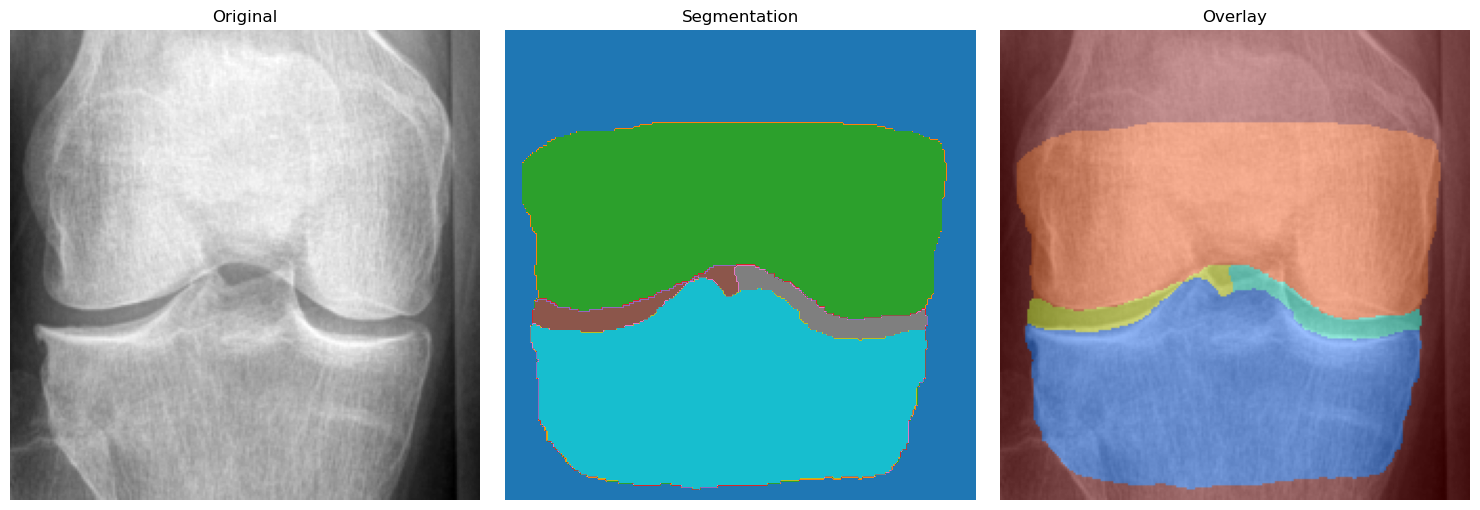

In [10]:
# =========================================================
# CELL 10
# SHOW SEGMENTATION
# =========================================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)

plt.imshow(original, cmap='gray')

plt.title("Original")

plt.axis('off')

plt.subplot(1,3,2)

plt.imshow(seg, cmap='tab10')

plt.title("Segmentation")

plt.axis('off')

overlay = cv2.applyColorMap(
    (seg*50).astype(np.uint8),
    cv2.COLORMAP_JET
)

plt.subplot(1,3,3)

plt.imshow(original, cmap='gray')

plt.imshow(overlay, alpha=0.4)

plt.title("Overlay")

plt.axis('off')

plt.tight_layout()

plt.show()

In [11]:
# =========================================================
# CELL 11
# EXTRACT ANATOMICAL MASKS
# =========================================================

femur = (seg==1).astype(np.float32)

lateral = (seg==2).astype(np.float32)

medial = (seg==3).astype(np.float32)

tibia = (seg==4).astype(np.float32)

print("Masks Extracted")

Masks Extracted


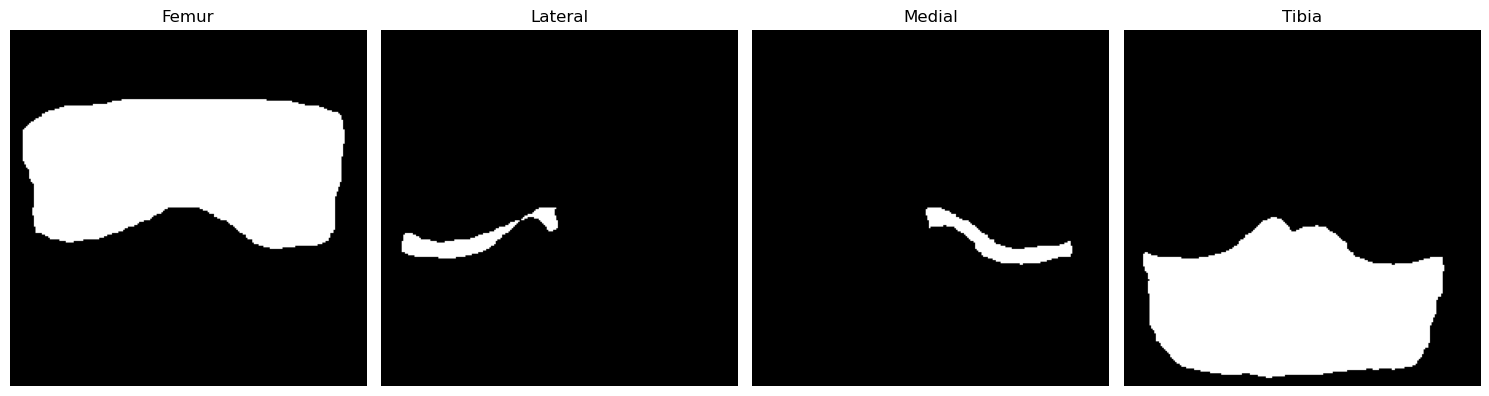

In [12]:
# =========================================================
# CELL 12
# SHOW MASKS
# =========================================================

masks = [
    femur,
    lateral,
    medial,
    tibia
]

titles = [
    "Femur",
    "Lateral",
    "Medial",
    "Tibia"
]

plt.figure(figsize=(15,5))

for i in range(4):

    plt.subplot(1,4,i+1)

    plt.imshow(masks[i], cmap='gray')

    plt.title(titles[i])

    plt.axis('off')

plt.tight_layout()

plt.show()

In [13]:
# =========================================================
# CELL 13
# FUSION
# =========================================================

jsn = prob_maps[0]

osteophyte = prob_maps[2]

JSN_medial = jsn * medial

JSN_lateral = jsn * lateral

OST_femur = osteophyte * femur

OST_tibia = osteophyte * tibia

JSN = (JSN_medial + JSN_lateral).sum()

OST = (OST_femur + OST_tibia).sum()

jsn_norm = JSN / (224*224)

ost_norm = OST / (224*224)

print("Fusion Complete")

Fusion Complete


In [14]:
# =========================================================
# CELL 15
# FINAL DECISION
# =========================================================

T_JSN_0  = 0.0492
T_JSN_12 = 0.0446
T_OST_12 = 0.0100

def predict_KL_2stage(jsn, osteophyte):

    # Stage 1
    if jsn > T_JSN_0:

        return 0

    # Stage 2
    if (jsn > T_JSN_12) and (osteophyte > T_OST_12):

        return 2

    else:

        return 1

pred = predict_KL_2stage(
    jsn_norm,
    ost_norm
)

In [15]:
# =========================================================
# CELL 16
# BINARY INTERPRETATION
# =========================================================

if pred == 0:

    final_label = "NORMAL"

else:

    final_label = "EARLY OSTEOARTHRITIS"

print("================================")
print("FINAL DIAGNOSIS")
print("================================")

print(final_label)


print("\nJSN Score:", round(jsn_norm,6))

print("OST Score:", round(ost_norm,6))

FINAL DIAGNOSIS
EARLY OSTEOARTHRITIS

JSN Score: 0.032678
OST Score: 0.0538
